# MIC-7489 V&V — modernized run vs released `model12.2`

Compares the output of a single `simulate run` on the modernized stack
(vivarium-engine 5.10 / vivarium-public-health 6.6.1) against the released
`model12.2` `psimulate` results.

The migration was **not** expected to reproduce `model12.2` exactly: engine 5.8.2
changed datetime randomness-key hashing, and this model keys common random numbers on
`[entrance_time, age]`, so in principle every CRN draw reshuffles. Other candidates for
moving the numbers: pandas 2 → 3, the vph `RiskEffect` relative-risk rework,
`allow_self_transition` now defaulting to `True`, and changed initializer registration
order.

This notebook therefore reports **two** comparisons, and lets the data decide:

| | Comparison | Question |
|---|---|---|
| **A** | matched cell, row by row | Are the runs bit-for-bit identical at the same draw/seed? |
| **B** | run vs the 100-seed spread | If not identical, does the run sit inside the reference Monte Carlo noise? |

**A** is the strong test. It is only meaningful because the run was configured to land on
a draw/seed that exists in `model12.2`; `simulate run` otherwise defaults to
`random_seed: 0` / `input_draw_number: 0`, neither of which is in the released keyspace.
If **A** passes there is nothing left to establish and **B** is redundant — but **B** is
computed regardless, since it is the honest fallback if any dataset diverges.

> **Read-only.** This notebook never writes to either results tree. The only path it
> writes is `CACHE_DIR`, a scratch directory outside both.

## Setup

In [1]:
from __future__ import annotations

import glob
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.compute as pc
import pyarrow.dataset as ds
import yaml

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

In [2]:
# --- the run under test -------------------------------------------------------------
NEW_RUN = Path(
    "/mnt/share/homes/sbachmei/scratch/alz/results/"
    "united_states_of_america/2026_09_23_09_15_23"
)

# --- the released comparison ---------------------------------------------------------
REF_ROOT = Path(
    "/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/results/model12.2"
)

# The run is one location / one scenario, so the reference must be filtered to match.
LOCATION_ARTIFACT = "united_states_of_america.hdf"
SCENARIO = "bbbm_testing_and_treatment"

# Filtered reference extracts are cached here to keep re-runs cheap. This is the ONLY
# path this notebook writes; both results trees are strictly read-only.
CACHE_DIR = Path("/mnt/share/homes/sbachmei/scratch/alz/vv_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Columns psimulate adds that a single simulate run does not produce.
KEYSPACE_COLS = ["artifact_path", "scenario", "input_draw", "random_seed"]

### Pin the draw and seed from the run's own metadata

`simulate run` writes `metadata.yaml` recording the draw and seed it actually used, so
these are read rather than assumed.

In [3]:
metadata = yaml.safe_load((NEW_RUN / "metadata.yaml").read_text())
DRAW = int(metadata["input_draw"])
SEED = int(metadata["random_seed"])

print(f"input_draw  : {DRAW}")
print(f"random_seed : {SEED}")
print(f"run time    : {metadata['simulation_run_time'] / 60:.1f} min")

input_draw  : 172
random_seed : 4344
run time    : 83.2 min


### Locate the batch holding this draw

`model12.2` was run in 12 batches. Each batch covers 2–3 input draws but **all 100
seeds**, so the draw alone determines which batch directory to read.

In [4]:
def find_batch_for_draw(draw: int) -> Path:
    """Return the results dir of the batch whose keyspace contains `draw`."""
    matches = []
    for keyspace_path in sorted(REF_ROOT.glob("batch*/model_spec/*/keyspace.yaml")):
        keyspace = yaml.safe_load(keyspace_path.read_text())
        if draw in keyspace.get("input_draw", []):
            matches.append(keyspace_path.parent / "results")
    if not matches:
        raise ValueError(f"draw {draw} is not present anywhere in {REF_ROOT}")
    if len(matches) > 1:
        raise ValueError(f"draw {draw} appears in multiple batches: {matches}")
    return matches[0]


REF_RESULTS = find_batch_for_draw(DRAW)
print(f"reference: {REF_RESULTS}")

# Confirm the seed exists too, so a silently-empty comparison is impossible.
keyspace = yaml.safe_load((REF_RESULTS.parent / "keyspace.yaml").read_text())
assert SEED in keyspace["random_seed"], f"seed {SEED} not in the released keyspace"
assert SCENARIO in keyspace["intervention.scenario"]
print(f"seed {SEED} and scenario {SCENARIO!r} both present in the keyspace")

reference: /mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/results/model12.2/batch1/model_spec/2026_02_13_12_41_14/results
seed 4344 and scenario 'bbbm_testing_and_treatment' both present in the keyspace


### Datasets to compare

In [5]:
NEW_MEASURES = {p.stem for p in (NEW_RUN / "results").glob("*.parquet")}
REF_MEASURES = {p.name for p in REF_RESULTS.iterdir() if p.is_dir()}

MEASURES = sorted(NEW_MEASURES & REF_MEASURES)
print(f"{len(MEASURES)} datasets compared")
for extra, side in [(NEW_MEASURES - REF_MEASURES, "run only"),
                    (REF_MEASURES - NEW_MEASURES, "reference only")]:
    if extra:
        print(f"  !! {side}: {sorted(extra)}")
MEASURES

14 datasets compared


['counts_baseline_tests_among_eligible',
 'counts_bbbm_tests',
 'counts_new_simulants',
 'counts_newly_eligible_for_bbbm_testing',
 'deaths',
 'person_time_alzheimers_disease_and_other_dementias',
 'person_time_eligible_for_bbbm_testing',
 'person_time_ever_eligible_for_bbbm_testing',
 'person_time_treatment',
 'transition_count_alzheimers_disease_and_other_dementias',
 'transition_count_treatment',
 'treatment_duration',
 'ylds',
 'ylls']

## Loading

In [6]:
def load_new(measure: str) -> pd.DataFrame:
    """The run under test. One location, one scenario, one draw, one seed."""
    return pd.read_parquet(NEW_RUN / "results" / f"{measure}.parquet")


def load_ref(measure: str, seed: int | None = None) -> pd.DataFrame:
    """Released results for this location/scenario/draw.

    Filters push down into the parquet scan -- reading a whole measure directory
    unfiltered is ~100M rows and will exhaust memory.

    `seed=None` returns all 100 seeds; an int returns just that one.
    """
    cache = CACHE_DIR / f"{measure}__draw{DRAW}__{SCENARIO}.parquet"
    if cache.exists():
        frame = pd.read_parquet(cache)
    else:
        predicate = (
            (pc.field("input_draw") == DRAW)
            & (pc.field("scenario") == SCENARIO)
            & pc.match_substring(pc.field("artifact_path"), LOCATION_ARTIFACT)
        )
        frame = (
            ds.dataset(REF_RESULTS / measure, format="parquet")
            .to_table(filter=predicate)
            .to_pandas()
            .drop(columns=["artifact_path", "scenario", "input_draw"])
        )
        frame.to_parquet(cache, index=False)
    return frame if seed is None else frame[frame["random_seed"] == seed]


def strata_of(frame: pd.DataFrame) -> list[str]:
    """Stratification columns: everything that is not the value or a keyspace column."""
    return [c for c in frame.columns if c not in {"value", *KEYSPACE_COLS}]

The first execution scans the released parquet files and takes a few minutes; afterwards
it reads from `CACHE_DIR`. Delete that directory to force a re-read.

In [7]:
%%time
reference = {measure: load_ref(measure) for measure in MEASURES}
run = {measure: load_new(measure) for measure in MEASURES}

print(f"cached {len(reference)} reference extracts in {CACHE_DIR}")

cached 14 reference extracts in /mnt/share/homes/sbachmei/scratch/alz/vv_cache
CPU times: user 5min 38s, sys: 47.4 s, total: 6min 26s
Wall time: 6min 27s


## A. Matched-cell comparison

Same draw, same seed, same scenario, same location — joined on the full stratification
key. An outer join with an indicator catches strata present on one side only, which a
naive value comparison would hide.

In [8]:
def compare_matched(measure: str) -> dict:
    new = run[measure]
    ref = reference[measure]
    ref = ref[ref["random_seed"] == SEED].drop(columns=["random_seed"])

    strata = strata_of(new)
    joined = new.merge(
        ref, on=strata, how="outer", suffixes=("_new", "_ref"), indicator=True
    )

    new_values = joined["value_new"]
    ref_values = joined["value_ref"]
    both = joined["_merge"] == "both"
    diff = (new_values.fillna(0) - ref_values.fillna(0)).abs()

    denominator = ref_values.abs().where(lambda s: s > 0)
    relative = (diff / denominator).replace([np.inf, -np.inf], np.nan)

    return {
        "dataset": measure,
        "rows": len(joined),
        "unmatched_strata": int((~both).sum()),
        "identical": bool(both.all() and np.allclose(new_values, ref_values, atol=0, rtol=0)),
        "n_differing": int((diff > 0).sum()),
        "max_abs_diff": float(diff.max()),
        "max_rel_diff": float(relative.max()) if relative.notna().any() else 0.0,
        "sum_new": float(new["value"].sum()),
        "sum_ref": float(ref["value"].sum()),
    }


matched = pd.DataFrame([compare_matched(m) for m in MEASURES])
matched["sum_pct_diff"] = np.where(
    matched["sum_ref"] != 0,
    100 * (matched["sum_new"] - matched["sum_ref"]) / matched["sum_ref"],
    np.nan,
)
matched.set_index("dataset")

,rows,unmatched_strata,identical,n_differing,max_abs_diff,max_rel_diff,sum_new,sum_ref,sum_pct_diff
dataset,,,,,,,,,
counts_baseline_tests_among_eligible,9480,0,True,0,0.0,0.0,1.841510e+05,1.841510e+05,0.0
counts_bbbm_tests,7110,0,True,0,0.0,0.0,7.070900e+04,7.070900e+04,0.0
counts_new_simulants,2370,0,True,0,0.0,0.0,3.038880e+05,3.038880e+05,0.0
counts_newly_eligible_for_bbbm_testing,7110,0,True,0,0.0,0.0,1.755300e+05,1.755300e+05,0.0
deaths,4740,0,True,0,0.0,0.0,2.817660e+05,2.817660e+05,0.0
person_time_alzheimers_disease_and_other_dementias,7110,0,True,0,0.0,0.0,3.091004e+06,3.091004e+06,0.0
person_time_eligible_for_bbbm_testing,7110,0,True,0,0.0,0.0,4.599052e+05,4.599052e+05,0.0
person_time_ever_eligible_for_bbbm_testing,21330,0,True,0,0.0,0.0,1.560501e+06,1.560501e+06,0.0
person_time_treatment,14220,0,True,0,0.0,0.0,3.091004e+06,3.091004e+06,0.0


In [9]:
all_identical = bool(matched["identical"].all())
no_missing_strata = int(matched["unmatched_strata"].sum()) == 0

print(f"datasets compared          : {len(matched)}")
print(f"bit-for-bit identical      : {int(matched['identical'].sum())} / {len(matched)}")
print(f"datasets with any diff     : {int((~matched['identical']).sum())}")
print(f"strata present on one side : {int(matched['unmatched_strata'].sum())}")
print(f"largest absolute diff      : {matched['max_abs_diff'].max():g}")
print()
if all_identical and no_missing_strata:
    print("VERDICT: exact reproduction of model12.2 at this draw/seed.")
else:
    print("VERDICT: differences present -- see the divergence and distribution sections.")

datasets compared          : 14
bit-for-bit identical      : 14 / 14
datasets with any diff     : 0
strata present on one side : 0
largest absolute diff      : 0

VERDICT: exact reproduction of model12.2 at this draw/seed.


### Where the differences are, if any

Skipped when section A is exact. When it is not, this ranks the worst strata so the
divergence can be attributed to an age group, year, sex, or transition rather than
treated as a single opaque number.

In [10]:
def worst_strata(measure: str, n: int = 15) -> pd.DataFrame:
    new = run[measure]
    ref = reference[measure]
    ref = ref[ref["random_seed"] == SEED].drop(columns=["random_seed"])

    strata = strata_of(new)
    joined = new.merge(ref, on=strata, how="outer", suffixes=("_new", "_ref"))
    joined["abs_diff"] = (joined["value_new"].fillna(0) - joined["value_ref"].fillna(0)).abs()
    joined["pct_diff"] = np.where(
        joined["value_ref"].abs() > 0,
        100 * (joined["value_new"] - joined["value_ref"]) / joined["value_ref"],
        np.nan,
    )
    return joined.nlargest(n, "abs_diff")[strata + ["value_new", "value_ref", "abs_diff", "pct_diff"]]


divergent = matched.loc[~matched["identical"], "dataset"].tolist()
if not divergent:
    print("No dataset differs at the matched draw/seed -- nothing to attribute.")
else:
    for measure in divergent:
        print(f"\n===== {measure} =====")
        display(worst_strata(measure))

No dataset differs at the matched draw/seed -- nothing to attribute.


## B. Run vs the 100-seed reference spread

The fallback comparison. Even a correct migration would not reproduce `model12.2`
simulant-for-simulant if the randomness keys rehash, so the meaningful question becomes
whether the run is a plausible draw from the same distribution.

Each reference seed is collapsed to a dataset total, giving 100 values; the run's total
is then placed within that distribution as a percentile and a z-score.

Treat this as **descriptive**. With n=1 it cannot establish equivalence — an extreme
percentile is evidence of a real shift, but a central one only means the run is not
obviously anomalous.

In [11]:
def seed_distribution(measure: str) -> dict:
    totals = reference[measure].groupby("random_seed")["value"].sum()
    observed = run[measure]["value"].sum()

    sd = float(totals.std(ddof=1))
    return {
        "dataset": measure,
        "run_total": observed,
        "ref_mean": float(totals.mean()),
        "ref_sd": sd,
        "ref_min": float(totals.min()),
        "ref_max": float(totals.max()),
        "matched_seed_total": float(totals.loc[SEED]),
        "pct_of_seeds_below": float(100 * (totals < observed).mean()),
        "z_score": float((observed - totals.mean()) / sd) if sd > 0 else np.nan,
        "inside_range": bool(totals.min() <= observed <= totals.max()),
    }


distribution = pd.DataFrame([seed_distribution(m) for m in MEASURES])
distribution.set_index("dataset")

,run_total,ref_mean,ref_sd,ref_min,ref_max,matched_seed_total,pct_of_seeds_below,z_score,inside_range
dataset,,,,,,,,,
counts_baseline_tests_among_eligible,1.841510e+05,1.842995e+05,382.377002,1.833530e+05,1.853940e+05,1.841510e+05,31.0,-0.388386,True
counts_bbbm_tests,7.070900e+04,7.033586e+04,281.163672,6.976900e+04,7.100100e+04,7.070900e+04,90.0,1.327127,True
counts_new_simulants,3.038880e+05,3.041955e+05,499.562444,3.028890e+05,3.054560e+05,3.038880e+05,28.0,-0.615479,True
counts_newly_eligible_for_bbbm_testing,1.755300e+05,1.754594e+05,369.609679,1.745600e+05,1.763440e+05,1.755300e+05,58.0,0.190985,True
deaths,2.817660e+05,2.819743e+05,481.570139,2.806360e+05,2.831520e+05,2.817660e+05,29.0,-0.432606,True
person_time_alzheimers_disease_and_other_dementias,3.091004e+06,3.093167e+06,5437.444275,3.081610e+06,3.111375e+06,3.091004e+06,32.0,-0.397802,True
person_time_eligible_for_bbbm_testing,4.599052e+05,4.603084e+05,1507.221252,4.562064e+05,4.641855e+05,4.599052e+05,39.0,-0.267522,True
person_time_ever_eligible_for_bbbm_testing,1.560501e+06,1.560379e+06,4502.406127,1.550513e+06,1.574619e+06,1.560501e+06,54.0,0.027118,True
person_time_treatment,3.091004e+06,3.093167e+06,5437.444275,3.081610e+06,3.111375e+06,3.091004e+06,32.0,-0.397802,True


In [12]:
outside = distribution.loc[~distribution["inside_range"], "dataset"].tolist()
print(f"datasets inside the reference seed range : "
      f"{int(distribution['inside_range'].sum())} / {len(distribution)}")
if outside:
    print(f"outside the range: {outside}")
else:
    print("every dataset total falls within the span of the 100 reference seeds")

datasets inside the reference seed range : 14 / 14
every dataset total falls within the span of the 100 reference seeds


### Distribution plots

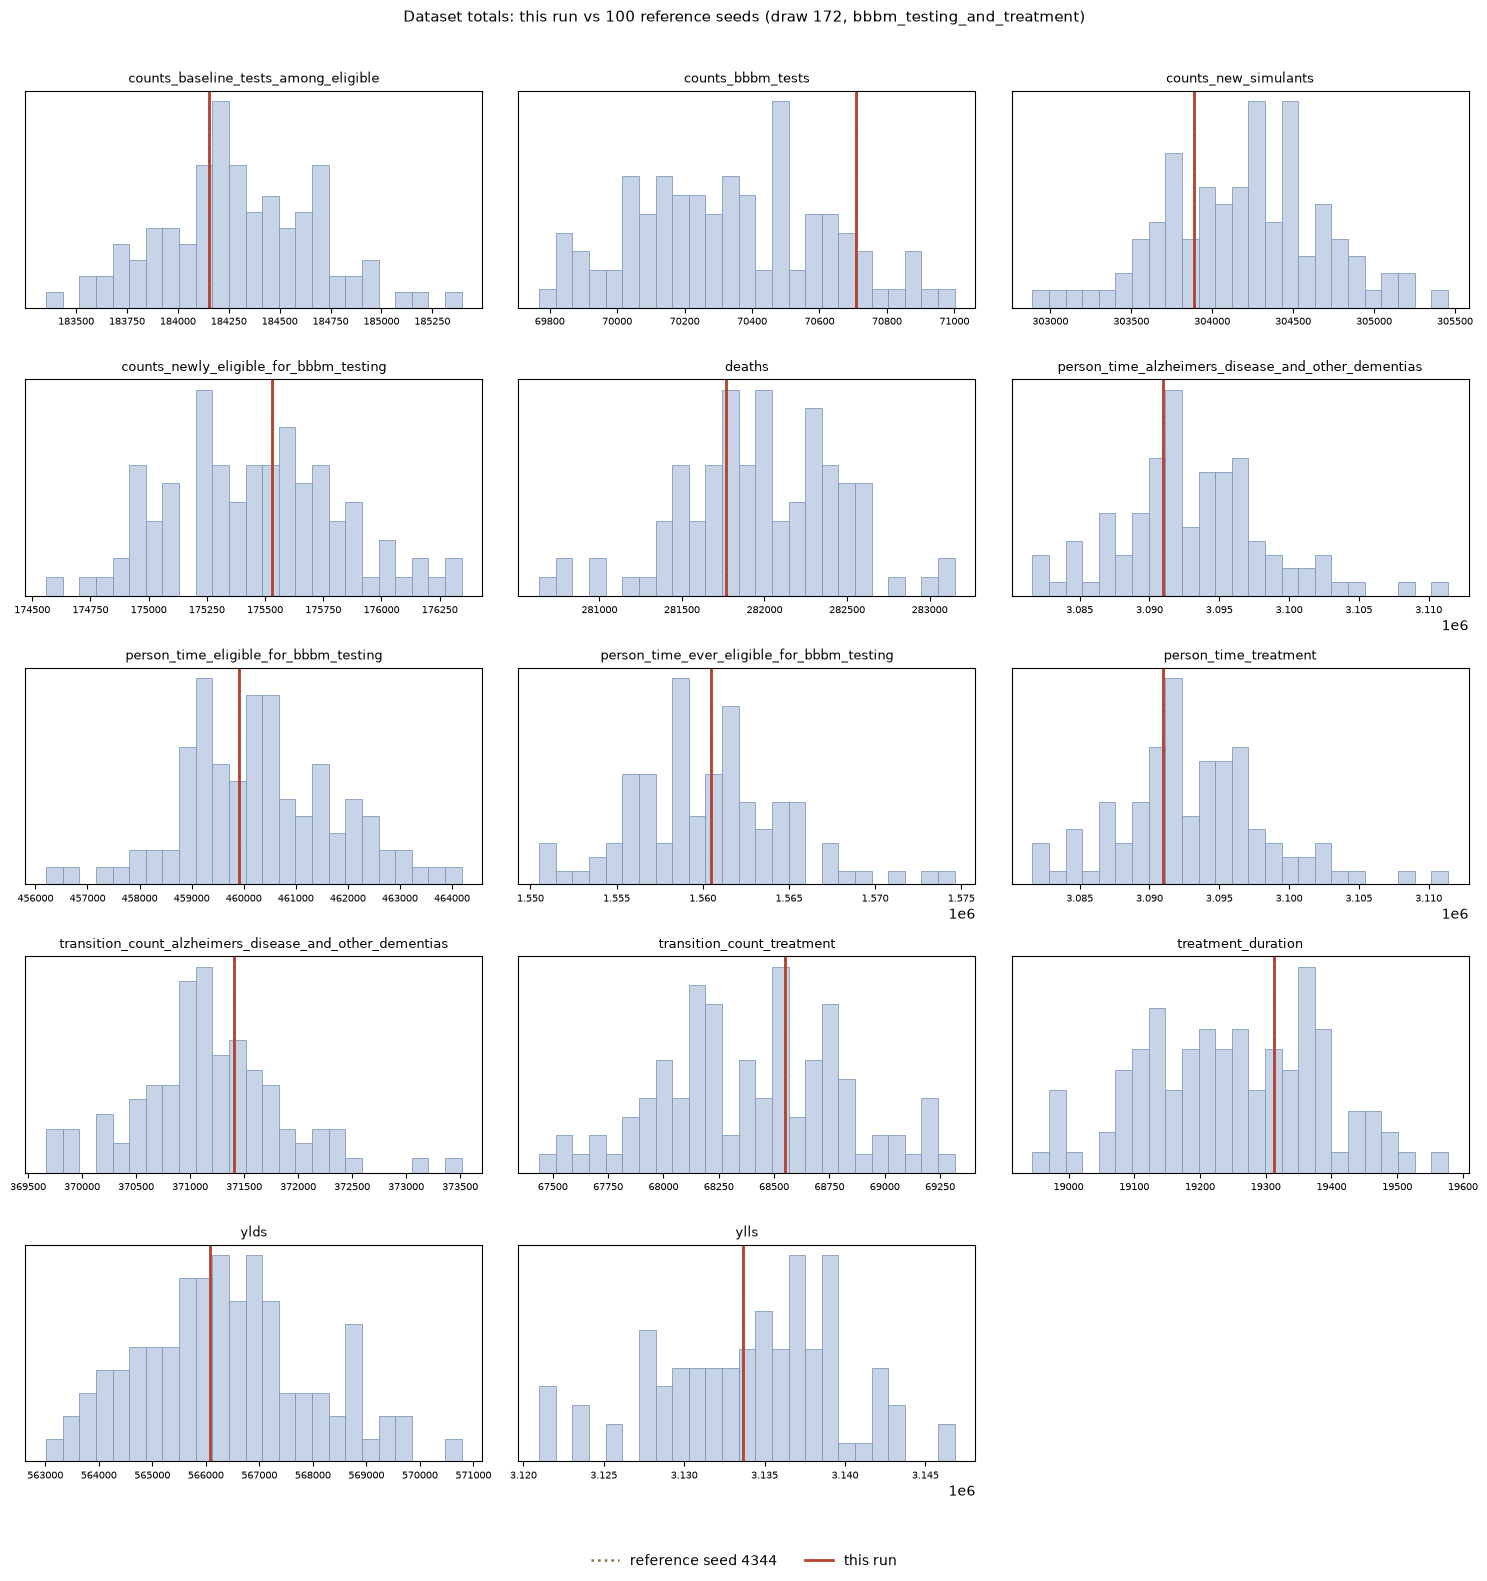

In [13]:
n_cols = 3
n_rows = int(np.ceil(len(MEASURES) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.2 * n_rows))

for ax, measure in zip(axes.flat, MEASURES):
    totals = reference[measure].groupby("random_seed")["value"].sum()
    observed = run[measure]["value"].sum()

    ax.hist(totals, bins=25, color="#c7d4e8", edgecolor="#6f8bb5", linewidth=0.5)
    ax.axvline(totals.loc[SEED], color="#8a6d3b", linestyle=":", linewidth=1.8,
               label=f"reference seed {SEED}")
    ax.axvline(observed, color="#b5432f", linewidth=2, label="this run")
    ax.set_title(measure, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.set_yticks([])

for ax in axes.flat[len(MEASURES):]:
    ax.set_visible(False)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)
fig.suptitle(
    f"Dataset totals: this run vs {len(reference[MEASURES[0]]['random_seed'].unique())} "
    f"reference seeds (draw {DRAW}, {SCENARIO})",
    fontsize=11,
)
fig.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.show()

When section A is exact the run line sits exactly on the matched-seed line, and the
histogram only illustrates how much spread the seed dimension carries — useful context
for how large a *real* regression would have to be before it cleared the noise.

## Summary

In [14]:
print(f"run        : {NEW_RUN}")
print(f"reference  : {REF_RESULTS}")
print(f"cell       : draw {DRAW}, seed {SEED}, {SCENARIO}, {LOCATION_ARTIFACT}")
print(f"datasets   : {len(MEASURES)}")
print()

if all_identical and no_missing_strata:
    print("A. matched cell : IDENTICAL across every dataset, every stratum.")
    print()
    print("   The modernized stack reproduces model12.2 exactly at this draw and seed.")
    print("   The randomness-key rehash did not perturb this model's CRN stream, so the")
    print("   migration is result-equivalent here -- a stronger outcome than expected.")
    print()
    print("   Scope: one draw, one seed, one scenario, one location. Exactness at one")
    print("   cell is strong evidence but does not prove it holds across the keyspace;")
    print("   re-run this notebook against other draws/seeds to widen it.")
else:
    n_diff = int((~matched['identical']).sum())
    print(f"A. matched cell : {n_diff} of {len(matched)} datasets differ.")
    print(f"B. seed spread  : {int(distribution['inside_range'].sum())} of "
          f"{len(distribution)} totals inside the reference range.")
    print()
    print("   Differences are expected in principle; judge them against the seed spread")
    print("   in section B rather than against zero.")

run        : /mnt/share/homes/sbachmei/scratch/alz/results/united_states_of_america/2026_09_23_09_15_23
reference  : /mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/results/model12.2/batch1/model_spec/2026_02_13_12_41_14/results
cell       : draw 172, seed 4344, bbbm_testing_and_treatment, united_states_of_america.hdf
datasets   : 14

A. matched cell : IDENTICAL across every dataset, every stratum.

   The modernized stack reproduces model12.2 exactly at this draw and seed.
   The randomness-key rehash did not perturb this model's CRN stream, so the
   migration is result-equivalent here -- a stronger outcome than expected.

   Scope: one draw, one seed, one scenario, one location. Exactness at one
   cell is strong evidence but does not prove it holds across the keyspace;
   re-run this notebook against other draws/seeds to widen it.
